In [60]:
### Importing required library 
import numpy as np 
from rdkit.Chem import AllChem
import pickle
import pandas as pd
from rdkit import Chem
import xgboost
import base64
import pickle
import numpy as np
import pandas as pd
from rdkit import Chem,DataStructs
from rdkit.Chem import MolFromSmiles, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
import base64
import shap
from xgboost import XGBRegressor
import xgboost as xgb
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import requests
from bs4 import BeautifulSoup
import deepchem as dc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import utilities  ### Created function to generate the descriptors 
from utilities import calculate_rdkit_features
from utilities import calculate_rdkit_features1
from utilities import calculate_aromatic_proportion

In [61]:
from rdkit import Chem
from rdkit.Chem import Descriptors  # For molecular descriptors in RDKit


In [62]:
#### All the function to create the descriptors 
import pandas as pd
def calculate_aromatic_proportion(smiles):
    # Parse SMILES string and generate molecular representation
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None  # Invalid SMILES
    
    # Identify aromatic atoms
    aromatic_atoms = [atom.GetAtomicNum() for atom in mol.GetAtoms() if atom.GetIsAromatic()]
    
    # Calculate aromatic proportion
    total_atoms = mol.GetNumAtoms()
    aromatic_proportion = len(aromatic_atoms) / total_atoms
    
    return aromatic_proportion
####  function for handling single smiles 
def calculate_rdkit_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        raise ValueError("Invalid SMILES string.")
    
    # List of RDKit descriptors
    descriptor_names = [desc[0] for desc in Descriptors._descList]
    descriptor_funcs = [desc[1] for desc in Descriptors._descList]
    
    # Compute descriptors
    features = [func(mol) for func in descriptor_funcs]
    
    # Create DataFrame
    df = pd.DataFrame([features], columns=descriptor_names)
    return df
#### Function for list of the smiles 
def calculate_rdkit_features1(smiles_list):
    """
    Calculate RDKit descriptors for a list of SMILES strings.

    Parameters:
        smiles_list (list of str): List of SMILES strings.

    Returns:
        pd.DataFrame: A DataFrame where each row corresponds to a SMILES string
                      and each column corresponds to a descriptor.
    """
    # List of RDKit descriptors
    descriptor_names = [desc[0] for desc in Descriptors._descList]
    descriptor_funcs = [desc[1] for desc in Descriptors._descList]

    data = []
    invalid_smiles = []

    for i, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if not mol:
            invalid_smiles.append((i, smiles))
            continue
        
        # Compute descriptors
        features = [func(mol) for func in descriptor_funcs]
        data.append(features)

    # Create DataFrame
    df = pd.DataFrame(data, columns=descriptor_names, index=[i for i, smiles in enumerate(smiles_list) if smiles not in dict(invalid_smiles)])

    # Log invalid SMILES strings
    if invalid_smiles:
        print(f"Invalid SMILES found at indices: {[idx for idx, sm in invalid_smiles]}\nInvalid SMILES: {[sm for idx, sm in invalid_smiles]}")

    return df
### function for single smiles and list of the smiles 
def fingerprint1(smiles, r, n): 
    # Check if input is a single SMILES string or a list
    if isinstance(smiles, str):
        smiles = [smiles]  # Convert single SMILES string to a list

    # Convert SMILES strings to RDKit molecules
    mols = [Chem.MolFromSmiles(SMILES_string) for SMILES_string in smiles]

    # Compute fingerprints
    fingerprints_array = []
    for m in mols:
        bi = {}
        fingerprint = rdMolDescriptors.GetMorganFingerprintAsBitVect(m, radius=r, nBits=n, bitInfo=bi)
        array = np.zeros((1,), dtype=int)
        DataStructs.ConvertToNumpyArray(fingerprint, array)
        fingerprints_array.append(array)

    # Convert to a DataFrame with bits as columns
    fingerprints_df = pd.DataFrame(fingerprints_array)

    # Return the DataFrame for a single SMILES
    return fingerprints_df
def get_charges(smiles):
    if '+' in smiles:
        return 1
    elif '-' in smiles:
        return -1
    else:
        return 0

def get_many_double_bonds(smiles):
    mol = Chem.MolFromSmiles(smiles)
    double_bond_count = sum(1 for bond in mol.GetBonds() if bond.GetBondType() == Chem.rdchem.BondType.DOUBLE)
    return 1 if double_bond_count > 4 else 0

def get_atom_degrees(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_degree_vector = np.zeros(7)
    for bond in bonds:
        atom1 = bond.GetBeginAtom()
        atom2 = bond.GetEndAtom()
        atom_degree_vector = np.array([1 if atom1.GetDegree() == d else 0 for d in range(7)])
        sum_degree_vector += atom_degree_vector
        atom_degree_vector = np.array([1 if atom2.GetDegree() == d else 0 for d in range(7)])
        sum_degree_vector += atom_degree_vector
    return sum_degree_vector.astype(int)

def get_atom_valences(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_valence_vector = np.zeros(7)
    for bond in bonds:
        atom1 = bond.GetBeginAtom()
        atom2 = bond.GetEndAtom()
        atom_valence_vector = np.array([1 if atom1.GetTotalValence() == v else 0 for v in range(7)])
        sum_valence_vector += atom_valence_vector
        atom_valence_vector = np.array([1 if atom2.GetTotalValence() == v else 0 for v in range(7)])
        sum_valence_vector += atom_valence_vector
    return sum_valence_vector.astype(int)

def get_atom_hybridization(smiles):
    hybridizations = [
        Chem.rdchem.HybridizationType.S,
        Chem.rdchem.HybridizationType.SP, 
        Chem.rdchem.HybridizationType.SP2, 
        Chem.rdchem.HybridizationType.SP3, 
        Chem.rdchem.HybridizationType.SP3D, 
        Chem.rdchem.HybridizationType.SP3D2, 
        Chem.rdchem.HybridizationType.UNSPECIFIED]
    
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_hybrid_vector = np.zeros(7)
    for bond in bonds:
        atom1 = bond.GetBeginAtom()
        atom2 = bond.GetEndAtom()
        atom_hybrid_vector = np.array([1 if atom1.GetHybridization() == h else 0 for h in hybridizations])
        sum_hybrid_vector += atom_hybrid_vector
        atom_hybrid_vector = np.array([1 if atom2.GetHybridization() == h else 0 for h in hybridizations])
        sum_hybrid_vector += atom_hybrid_vector
    return sum_hybrid_vector.astype(int)

def get_aromatic_atoms(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_aromatic_vector = np.zeros(1)
    for bond in bonds:
        atom1 = bond.GetBeginAtom()
        atom2 = bond.GetEndAtom()
        atom_aromatic_vector = np.array([1 if atom1.GetIsAromatic() else 0])
        sum_aromatic_vector += atom_aromatic_vector
        atom_aromatic_vector = np.array([1 if atom2.GetIsAromatic() else 0])
        sum_aromatic_vector += atom_aromatic_vector
    return sum_aromatic_vector.astype(int)[0]

def get_bond_types(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_bond_type_vector = np.zeros(5)
    for bond in bonds:
        bond_type = bond.GetBondType().name
        bond_type_vector = np.array([1 if t == bond_type else 0 for t in ['SINGLE', 'DOUBLE', 'TRIPLE', 'AROMATIC', 'ZERO']])
        sum_bond_type_vector += bond_type_vector
    return sum_bond_type_vector.astype(int)

def is_conjugated(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_conjugated = np.zeros(1)
    for bond in bonds:
        is_conjugated = 1 if bond.GetIsConjugated() else 0
        conjugation_vector = np.array([is_conjugated])
        sum_conjugated += conjugation_vector
    return sum_conjugated.astype(int)[0]

def get_bonds_in_ring(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    return len(Chem.GetSymmSSSR(mol))

def get_bond_chirality(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_chirality = np.zeros(4)
    for bond in bonds:
        chirality = bond.GetStereo()
        chirality_vector = np.array([1 if chirality == c else 0 for c in [Chem.rdchem.BondStereo.STEREONONE,
                                                                          Chem.rdchem.BondStereo.STEREOANY,
                                                                          Chem.rdchem.BondStereo.STEREOZ,
                                                                          Chem.rdchem.BondStereo.STEREOE]])
        sum_chirality += chirality_vector
    return sum_chirality.astype(int)

def get_n_atoms(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    return mol.GetNumAtoms()

def get_n_bonds(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    return mol.GetNumBonds()

def get_n_rings(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    return len(Chem.GetSymmSSSR(mol))
### Funntion for creating 38 features for single smiles 
def generate_features_single38(smiles):
    columns = [
        'charge', 'many_double_bonds', 'atoms_degree_0', 'atoms_degree_1',
        'atoms_degree_2', 'atoms_degree_3', 'atoms_degree_4', 'atoms_degree_5',
        'atoms_degree_6', 'atoms_valence_0', 'atoms_valence_1', 'atoms_valence_2',
        'atoms_valence_3', 'atoms_valence_4', 'atoms_valence_5', 'atoms_valence_6',
        'atom_hybridization_S', 'atom_hybridization_SP', 'atom_hybridization_SP2',
        'atom_hybridization_SP3', 'atom_hybridization_SP3D', 'atom_hybridization_SP3D2',
        'atom_hybridization_UNSPECIFIED', 'aromatic_atoms', 'single_bonds', 'double_bonds',
        'triple_bonds', 'aromatic_bonds', 'zero_bonds', 'conjugated_bonds', 'bonds_in_ring',
        'chirality_none', 'chirality_any', 'chirality_z', 'chirality_e', 'n_atoms',
        'n_bonds', 'n_rings'
    ]

    # Calculate features for the single SMILES string
    charge = get_charges(smiles)
    many_double_bonds = get_many_double_bonds(smiles)
    atom_degrees = get_atom_degrees(smiles).tolist()
    atom_valences = get_atom_valences(smiles).tolist()
    atom_hybridizations = get_atom_hybridization(smiles).tolist()
    aromatic_atoms = get_aromatic_atoms(smiles)
    bond_types = get_bond_types(smiles).tolist()
    conjugated_bonds = is_conjugated(smiles)
    bonds_in_ring = get_bonds_in_ring(smiles)
    bond_chirality = get_bond_chirality(smiles).tolist()
    n_atoms = get_n_atoms(smiles)
    n_bonds = get_n_bonds(smiles)
    n_rings = get_n_rings(smiles)

    # Combine all features into a single row
    feature_row = [
        charge, many_double_bonds, atom_degrees[0], atom_degrees[1],
        atom_degrees[2], atom_degrees[3], atom_degrees[4], atom_degrees[5],
        atom_degrees[6], atom_valences[0], atom_valences[1], atom_valences[2],
        atom_valences[3], atom_valences[4], atom_valences[5], atom_valences[6],
        atom_hybridizations[0], atom_hybridizations[1], atom_hybridizations[2],
        atom_hybridizations[3], atom_hybridizations[4], atom_hybridizations[5],
        atom_hybridizations[6], aromatic_atoms, bond_types[0], bond_types[1],
        bond_types[2], bond_types[3], bond_types[4], conjugated_bonds,
        bonds_in_ring, bond_chirality[0], bond_chirality[1], bond_chirality[2],
        bond_chirality[3], n_atoms, n_bonds, n_rings
    ]

    # Convert the feature row into a DataFrame
    return pd.DataFrame([feature_row], columns=columns)
#### function for creating the 38 features for list of the smiles 
def generate_features38(smiles_list):
    columns = [
        'charge', 'many_double_bonds', 'atoms_degree_0', 'atoms_degree_1',
        'atoms_degree_2', 'atoms_degree_3', 'atoms_degree_4', 'atoms_degree_5',
        'atoms_degree_6', 'atoms_valence_0', 'atoms_valence_1', 'atoms_valence_2',
        'atoms_valence_3', 'atoms_valence_4', 'atoms_valence_5', 'atoms_valence_6',
        'atom_hybridization_S', 'atom_hybridization_SP', 'atom_hybridization_SP2',
        'atom_hybridization_SP3', 'atom_hybridization_SP3D', 'atom_hybridization_SP3D2',
        'atom_hybridization_UNSPECIFIED', 'aromatic_atoms', 'single_bonds', 'double_bonds',
        'triple_bonds', 'aromatic_bonds', 'zero_bonds', 'conjugated_bonds', 'bonds_in_ring',
        'chirality_none', 'chirality_any', 'chirality_z', 'chirality_e', 'n_atoms',
        'n_bonds', 'n_rings'
    ]
    
    features = []
    for smiles in smiles_list:
        charge = get_charges(smiles)
        many_double_bonds = get_many_double_bonds(smiles)
        atom_degrees = get_atom_degrees(smiles).tolist()
        atom_valences = get_atom_valences(smiles).tolist()
        atom_hybridizations = get_atom_hybridization(smiles).tolist()
        aromatic_atoms = get_aromatic_atoms(smiles)
        bond_types = get_bond_types(smiles).tolist()
        conjugated_bonds = is_conjugated(smiles)
        bonds_in_ring = get_bonds_in_ring(smiles)
        bond_chirality = get_bond_chirality(smiles).tolist()
        n_atoms = get_n_atoms(smiles)
        n_bonds = get_n_bonds(smiles)
        n_rings = get_n_rings(smiles)

        feature_row = [
            charge, many_double_bonds, atom_degrees[0], atom_degrees[1],
            atom_degrees[2], atom_degrees[3], atom_degrees[4], atom_degrees[5],
            atom_degrees[6], atom_valences[0], atom_valences[1], atom_valences[2],
            atom_valences[3], atom_valences[4], atom_valences[5], atom_valences[6],
            atom_hybridizations[0], atom_hybridizations[1], atom_hybridizations[2],
            atom_hybridizations[3], atom_hybridizations[4], atom_hybridizations[5],
            atom_hybridizations[6], aromatic_atoms, bond_types[0], bond_types[1],
            bond_types[2], bond_types[3], bond_types[4], conjugated_bonds,
            bonds_in_ring, bond_chirality[0], bond_chirality[1], bond_chirality[2],
            bond_chirality[3], n_atoms, n_bonds, n_rings
        ]
        
        features.append(feature_row)
    
    return pd.DataFrame(features, columns=columns)

### Function for 7 groups for single smiles and list of the smiles 
def get_functional_groups1(smiles):
    from rdkit import Chem
    import pandas as pd

    functional_groups = {
        # Polar functional groups
        'Hydroxyl Group': '[OH]',
        'Carbonyl Group': 'C=O',
        'Amide Group': 'C(=O)N',
        'Carboxyl Group': 'C(=O)[OH]',
        # Non-polar functional groups
        'Alkyl': '[R]', 
        'Aromatic Rings': 'c',
        'Alkene': 'C=C'
    }
    
    # Check if input is a single SMILES string
    if isinstance(smiles, str):
        smiles = [smiles]  # Wrap it in a list for consistency
    
    results = []
    for s in smiles:
        mol = Chem.MolFromSmiles(s)
        if mol:  # Ensure valid SMILES
            fg_presence = {fg: 1 if mol.HasSubstructMatch(Chem.MolFromSmarts(smarts)) else 0 for fg, smarts in functional_groups.items()}
        else:
            fg_presence = {fg: 0 for fg in functional_groups}  # Default to 0 if SMILES is invalid
        #fg_presence['SMILES'] = s
        results.append(fg_presence)
    
    # Convert results to a DataFrame
    data = pd.DataFrame(results)
    
    return data
### for single smiles 
def calc_mol_weight(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Descriptors.MolWt(mol)
    return None
#### for smiles list 
def calc_mol_weight1(smiles_list):
    """
    Calculate molecular weights for a list of SMILES strings.

    Parameters:
        smiles_list (list of str): List of SMILES strings.

    Returns:
        list: Molecular weights for valid SMILES strings, or None for invalid ones.
    """
    return [
        Descriptors.MolWt(Chem.MolFromSmiles(smiles)) if Chem.MolFromSmiles(smiles) else None
        for smiles in smiles_list
    ]


In [23]:
train_set=pd.read_csv('unique_train4_new26.csv')

In [24]:
SMILES=train_set.smiles_canon

In [25]:
### Function to create descriptors for multiple smiles
def create_feature_multiple(SMILES):
        df125_new=calculate_rdkit_features1(SMILES)
        df125 = df125_new.iloc[:, :125]
        df38=generate_features38(SMILES)
        df128=fingerprint1(SMILES,2,128)
        df7=get_functional_groups1(SMILES)
        return pd.concat([df125, df128, df7, df38], axis=1)


In [26]:
### Function to create descriptors for single smiles
def create_feature_single(SMILES):
    df125_new = calculate_rdkit_features(SMILES1)
    df125 = df125_new.iloc[:, :125]
    df38 = generate_features_single38(SMILES1)
    df128 = fingerprint1(SMILES1, 2, 128)
    df7 = get_functional_groups1(SMILES1)

    return pd.concat([df125, df128, df7, df38], axis=1)
    

In [27]:
combined_df=create_feature_multiple(SMILES)

[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not removing hydrogen atom without neighbors
[13:23:40] WARNING: not r

In [28]:
SMILES1= 'CC(C)(C)C(C)(C)C(C)(C)C(C)(C)C(C)(C)C(C)(C)C'
new_molecule_vector = create_feature_single(SMILES1)
training_set_vectors = np.array(combined_df)  # Ensure it's a NumPy array
new_molecule_vector = np.array(new_molecule_vector).reshape(1, -1) 

In [133]:
training_set_vectors = np.array(combined_df)  # Ensure it's a NumPy array
new_molecule_vector = np.array(new_molecule_vector).reshape(1, -1)  

In [134]:
def clean_data(data):
    """Fixes NaN, Infinity, and extreme values in the dataset."""
    data = np.array(data, dtype=np.float64)

    # Replace NaN with the mean (or 0 if all values are NaN)
    nan_mask = np.isnan(data)
    if np.any(nan_mask):
        mean_value = np.nanmean(data) if not np.all(nan_mask) else 0.0
        data[nan_mask] = mean_value  # Replace NaNs

    # Replace Infinity with a large finite number
    inf_mask = np.isinf(data)
    data[inf_mask] = np.sign(data[inf_mask]) * 1e6  # Replace +inf with 1e6, -inf with -1e6

    # Clip excessively large values
    data = np.clip(data, -1e6, 1e6)

    return data

# Clean the data
training_set_vectors = clean_data(training_set_vectors)
new_molecule_vector = clean_data(new_molecule_vector)
scaler = StandardScaler()
training_set_vectors_scaled = scaler.fit_transform(training_set_vectors)
new_molecule_vector_scaled = scaler.transform(new_molecule_vector)


In [136]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [137]:
scaler = StandardScaler()
training_set_vectors_scaled = scaler.fit_transform(training_set_vectors)
new_molecule_scaled = scaler.transform(new_molecule_vector) 
# Step 3: Reduce dimensionality to 2D using PCA (for speed in t-SNE)
pca = PCA(n_components=50)  # Reduce to 50 components before t-SNE
training_set_vectors_pca = pca.fit_transform(training_set_vectors_scaled)
new_molecule_pca = pca.transform(new_molecule_scaled) 

# Step 4: Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
training_set_vectors_tsne = tsne.fit_transform(training_set_vectors_pca)


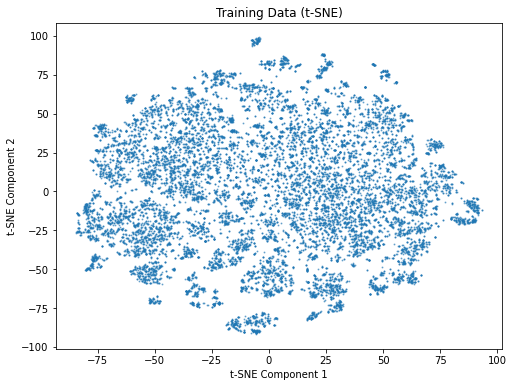

In [66]:
# Step 5: Plot the reduced training data (2D)
plt.figure(figsize=(8, 6))
plt.scatter(training_set_vectors_tsne[:, 0], training_set_vectors_tsne[:, 1], s=1, alpha=0.5, label="Training Data")
plt.title("Training Data (t-SNE)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

In [89]:
# Check for NaN or infinite values in the new molecule vector
if np.any(np.isnan(new_molecule_vector)) or np.any(np.isinf(new_molecule_vector)):
    print("Error: new_molecule_vector contains NaN or infinite values.")
else:
    print("new_molecule_vector is clean.")

# Check for NaN or infinite values in the training set vectors
if np.any(np.isnan(training_set_vectors)) or np.any(np.isinf(training_set_vectors)):
    print("Error: training_set_vectors contains NaN or infinite values.")
else:
    print("training_set_vectors is clean.")

new_molecule_vector is clean.
training_set_vectors is clean.


In [90]:
print("Shape of new_molecule_vector:", new_molecule_vector.shape)
print("Shape of training_set_vectors:", training_set_vectors.shape)


Shape of new_molecule_vector: (1, 298)
Shape of training_set_vectors: (17937, 298)


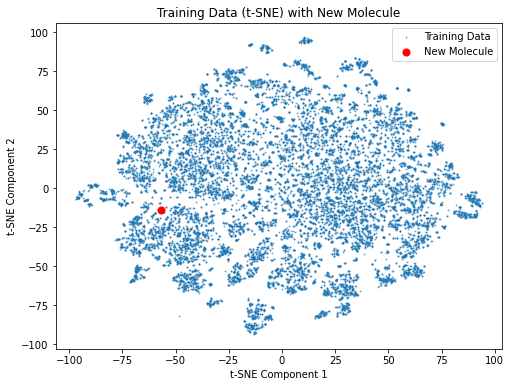

In [91]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Assuming new_molecule_pca is already PCA-transformed and is a single sample
# Assuming training_set_vectors_pca is your PCA-transformed training set (multiple samples)

# Ensure new_molecule_pca is reshaped to 2D if it's a 1D array
if new_molecule_pca.ndim == 1:
    new_molecule_pca = new_molecule_pca.reshape(1, -1)
pca = PCA(n_components=50)  # Reduce to 50 components before t-SNE
training_set_vectors_pca = pca.fit_transform(training_set_vectors_scaled)
new_molecule_pca = pca.transform(new_molecule_scaled) 
# Combine new molecule with the training set for t-SNE fitting
combined_vectors_pca = np.vstack([training_set_vectors_pca, new_molecule_pca])

# Initialize t-SNE
tsne = TSNE(n_components=2, random_state=42)

# Fit t-SNE to the combined data
combined_vectors_tsne = tsne.fit_transform(combined_vectors_pca)

# Extract t-SNE coordinates for the new molecule (last row)
new_molecule_tsne = combined_vectors_tsne[-1]

# Extract t-SNE coordinates for the training data
training_set_vectors_tsne = combined_vectors_tsne[:-1]

# Visualize or use the transformed data
plt.figure(figsize=(8, 6))
plt.scatter(training_set_vectors_tsne[:, 0], training_set_vectors_tsne[:, 1], s=1, alpha=0.5, label="Training Data")
plt.scatter(new_molecule_tsne[0], new_molecule_tsne[1], color='red', label="New Molecule", s=50)
plt.title("Training Data (t-SNE) with New Molecule")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()


In [175]:
#### Testing for different smiles with different molecular weight 
#SMILES1= 'CC(C)(C)C(C)(C)C(C)(C)C(C)(C)C(C)(C)C(C)(C)C'  # Mw 282 
#SMILES1= 'C12(N)CC3CC(C1)CC(C2)C3'  ##MW 151 
## MW 1202 
SMILES1='CCC1C(=O)N(CC(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(C(=O)NC(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N1)C(C(C)CC=CC)O)C)C(C)C)C)CC(C)C)C)CC(C)C)C)C)C)CC(C)C)C)C(C)C)CC(C)C)C)C'
new_molecule_vector = create_feature_single(SMILES1)
### Loading saved trainning set vectors 
training_set_vectors = np.load("training_set_vectors.npy")  # Ensure it's a NumPy array
new_molecule_vector = np.array(new_molecule_vector).reshape(1, -1) 
scaler = StandardScaler()
training_set_vectors_scaled = scaler.fit_transform(training_set_vectors)
new_molecule_scaled = scaler.transform(new_molecule_vector) 
pca = PCA(n_components=50)  # Reduce to 50 components before t-SNE
training_set_vectors_pca = pca.fit_transform(training_set_vectors_scaled)
new_molecule_pca = pca.transform(new_molecule_scaled) 

if new_molecule_pca.ndim == 1:
    new_molecule_pca = new_molecule_pca.reshape(1, -1)
# Combine new molecule with the training set for t-SNE fitting
combined_vectors_pca = np.vstack([training_set_vectors_pca, new_molecule_pca])

# Initialize t-SNE
tsne = TSNE(n_components=2, random_state=42)

# Fit t-SNE to the combined data
combined_vectors_tsne = tsne.fit_transform(combined_vectors_pca)

# Extract t-SNE coordinates for the new molecule (last row)
new_molecule_tsne1 = combined_vectors_tsne[-1]
# # Extract t-SNE coordinates for the training data
training_set_vectors_tsne1 = combined_vectors_tsne[:-1]


In [179]:
def is_in_domain(tsne_new_point, tsne_data, threshold_distance=0.76):
    # Calculate the distance between the new molecule and the closest training data point
    distances = np.linalg.norm(tsne_data - tsne_new_point, axis=1)
    distances = np.round(distances, decimals=5)
    min_distance = np.min(distances)
    print(min_distance)
    print(threshold_distance)
    if min_distance < threshold_distance:
        return "The compound is within the Applicability Domain."
    else:
        return "Warning: Molecule is outside the model's applicability domain. Prediction may be unreliable."

# Assuming new_molecule_tsne is a 2D array with shape (1, 2), you need to pass the full point
result = is_in_domain(new_molecule_tsne1, training_set_vectors_tsne1)  # Pass the full 2D point
print(result)

1.53495
0.76


In [170]:
### Method 1: Percentile-Based Distance Threshold (Recommended)

from scipy.spatial.distance import cdist
import numpy as np

# Compute pairwise distances between all training data in t-SNE space
pairwise_distances = cdist(training_set_vectors_tsne, training_set_vectors_tsne)

# Find the minimum distance to any other point for each molecule
min_distances = np.min(pairwise_distances + np.eye(pairwise_distances.shape[0]) * 1e10, axis=1)

# Set threshold as the 95th percentile of minimum distances
threshold_distance = np.percentile(min_distances, 95)

print(f"Optimal t-SNE threshold: {threshold_distance}")



Optimal t-SNE threshold: 0.6682287638903679


In [177]:
###Method 2: Using k-Nearest Neighbors (k-NN) Distances

from sklearn.neighbors import NearestNeighbors

k = 5  # Consider the 5th nearest neighbor distance
nbrs = NearestNeighbors(n_neighbors=k).fit(training_set_vectors_tsne)
distances, _ = nbrs.kneighbors(training_set_vectors_tsne)

# Use the mean of the 5th nearest neighbor distances
threshold_distance = np.mean(distances[:, -1])

print(f"Optimal t-SNE threshold: {threshold_distance}")


Optimal t-SNE threshold: 0.7698142973003042


In [178]:
### Method 3: Mean + Standard Deviation Heuristic
# Compute mean and standard deviation of minimum distances
mean_distance = np.mean(min_distances)
std_distance = np.std(min_distances)

# Define threshold (mean + 1.5 * std)
threshold_distance = mean_distance + 1.5 * std_distance

print(f"Optimal t-SNE threshold: {threshold_distance}")


Optimal t-SNE threshold: 0.5903091916524873
